# Notebook 01 — Data Import & Quality Control
## Non-Invasive Paternity & Kinship Analysis in Wild Mountain Gorillas

---

**Pipeline step:** Raw data → QC-filtered genotypes  
**Key outputs:** Missing data rates, HWE tests, PIC per locus, QC-filtered dataset

---

In [32]:
# Cell 1 — Install dependencies (run once; comment out after)
# !pip install numpy pandas scipy matplotlib seaborn plotly networkx statsmodels scikit-allel pingouin tqdm openpyxl
print('Dependencies assumed installed. Uncomment the line above if needed.')

Dependencies assumed installed.


In [33]:
# Cell 2 — Generate data (run this if data/raw/ CSVs don't exist yet)
import subprocess, sys, os
from pathlib import Path

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

gen_script = ROOT / 'scripts' / 'data_generator.py'
data_check = ROOT / 'data' / 'raw' / 'individuals.csv'

if not data_check.exists():
    print('Generating synthetic dataset...')
    result = subprocess.run([sys.executable, str(gen_script)], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print('ERROR:', result.stderr)
else:
    print(f'Data already exists at {data_check.parent}')

Data already exists at c:\Users\User\Desktop\gorilla-paternity-analysis\data\raw


In [34]:
# Cell 3 — Imports
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2

# Add scripts/ to path
ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

from utils import (
    LOCUS_NAMES, AGE_CLASS_ORDER, COLOUR_MAP,
    missing_data_summary, individual_missing_data,
    missing_data_matrix, set_plot_style, save_figure,
    get_data_dir, get_output_dir
)
from parentage_functions import (
    build_freq_table, pic_per_locus, hwe_exact_chi2,
    exclusion_probability_per_locus, combined_exclusion_probability
)

set_plot_style()
DATA_DIR      = get_data_dir('raw')
PROC_DIR      = get_data_dir('processed')
FIG_DIR       = get_output_dir('figures')
TAB_DIR       = get_output_dir('tables')

print('Imports OK.')
print(f'Project root : {ROOT}')
print(f'Data dir     : {DATA_DIR}')

Imports OK.
Project root : c:\Users\User\Desktop\gorilla-paternity-analysis
Data dir     : c:\Users\User\Desktop\gorilla-paternity-analysis\data\raw


In [35]:
# Cell 4 — Load raw data
ind_df   = pd.read_csv(DATA_DIR / 'individuals.csv')
geno_df  = pd.read_csv(DATA_DIR / 'genotypes.csv')
groups_df= pd.read_csv(DATA_DIR / 'groups.csv')

print('=== INDIVIDUALS ===')
print(f'  Shape: {ind_df.shape}')
print(f'  Columns: {list(ind_df.columns)}')
print()
print('=== GENOTYPES ===')
print(f'  Shape: {geno_df.shape}  (individuals × 2*loci+1 columns)')
print(f'  Loci detected: {len(LOCUS_NAMES)}')
print()
print('=== GROUPS ===')
print(groups_df.to_string(index=False))

=== INDIVIDUALS ===
  Shape: (63, 8)
  Columns: ['individual_id', 'name', 'sex', 'age_class', 'group_id', 'dominance_rank', 'mother_id', 'true_father_id']

=== GENOTYPES ===
  Shape: (63, 31)  (individuals × 2*loci+1 columns)
  Loci detected: 15

=== GROUPS ===
id     name  location
G1     Susa Karisimbi
G2  Amahoro Karisimbi
G3  Umubano    Bisoke
G4 Sabyinyo  Sabyinyo
G5    Hirwa  Muhabura
G6 Kwitonda  Muhabura


In [36]:
# Cell 5 — Cohort demographics overview
print('--- Age class breakdown ---')
print(ind_df['age_class'].value_counts())
print()
print('--- Sex breakdown ---')
print(ind_df['sex'].value_counts())
print()
print('--- Per-group summary ---')
grp_summary = ind_df.groupby('group_id').agg(
    n_total=('individual_id','count'),
    n_males=('sex', lambda x: (x=='M').sum()),
    n_females=('sex', lambda x: (x=='F').sum()),
    n_offspring=('age_class', lambda x: x.isin(['infant','juvenile']).sum()),
    n_silverbacks=('age_class', lambda x: (x=='silverback').sum())
).reset_index().merge(groups_df[['id','name']], left_on='group_id', right_on='id')
print(grp_summary[['name','n_total','n_silverbacks','n_females','n_offspring']].to_string(index=False))

# Save table
grp_summary.to_csv(TAB_DIR / 'cohort_summary.csv', index=False)

--- Age class breakdown ---
age_class
adult         31
infant        13
silverback    12
juvenile       7
Name: count, dtype: int64

--- Sex breakdown ---
sex
F    41
M    22
Name: count, dtype: int64

--- Per-group summary ---
    name  n_total  n_silverbacks  n_females  n_offspring
    Susa       10              3          6            3
 Amahoro       10              2          5            4
 Umubano       12              1          9            5
Sabyinyo        9              2          5            2
   Hirwa       13              3          9            4
Kwitonda        9              1          7            2


  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\01_cohort_demographics.png


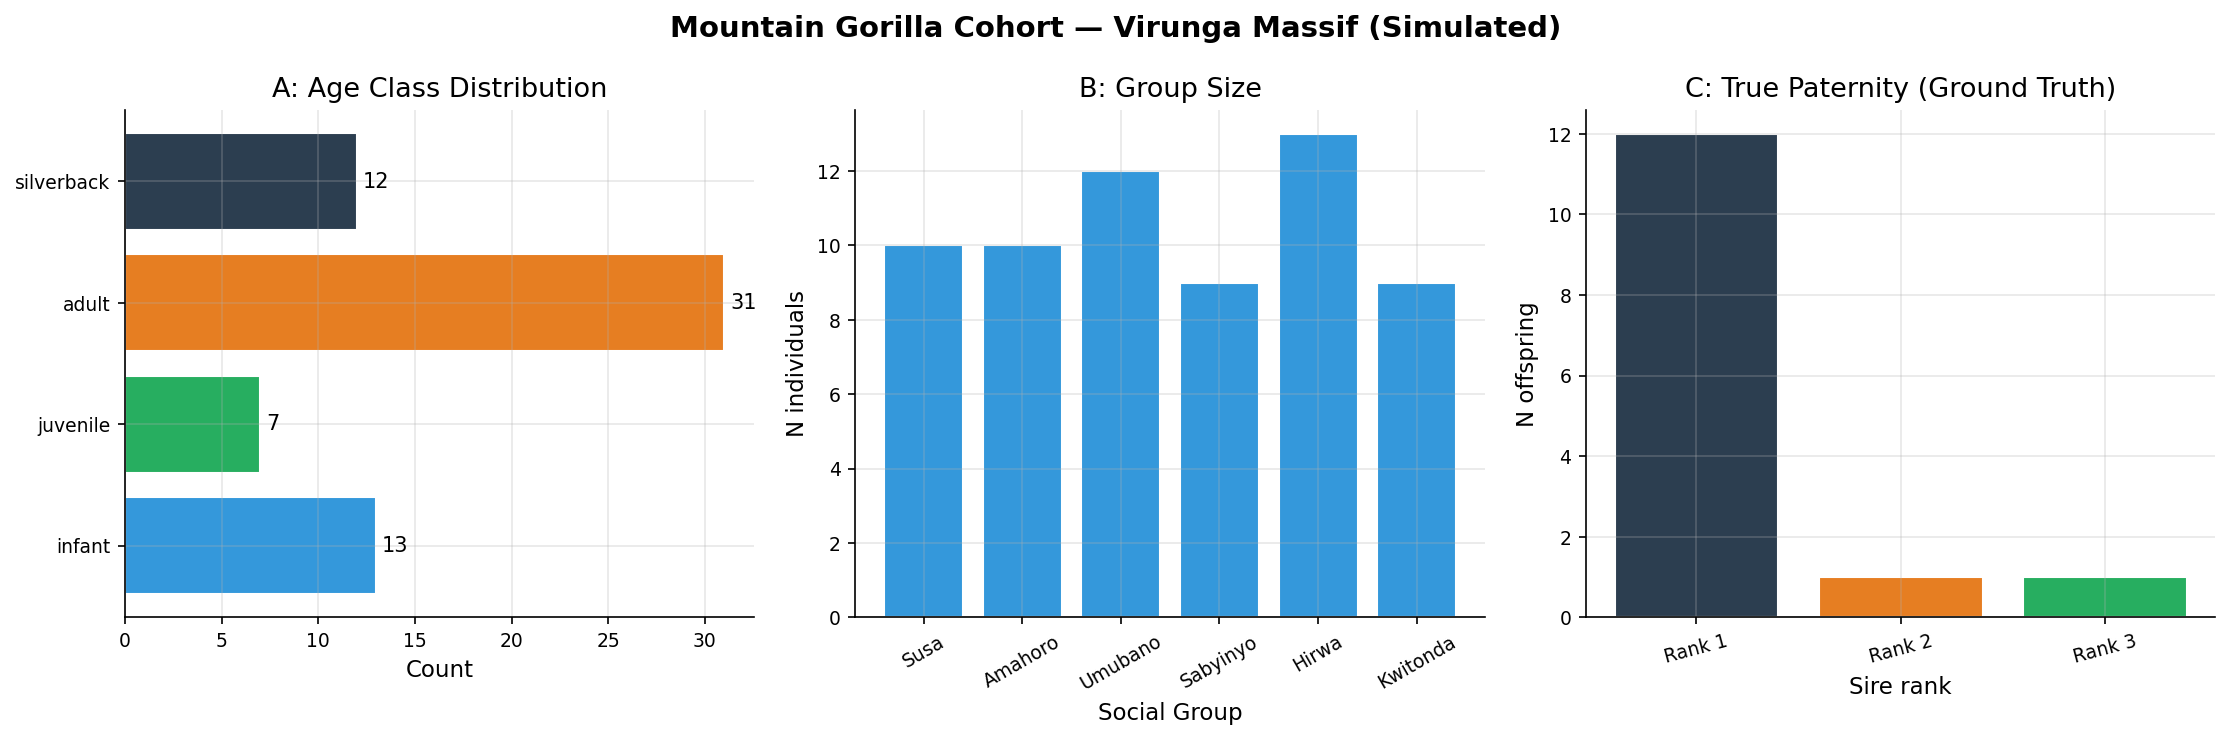

In [37]:
# Cell 6 — Visualise cohort demographics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Mountain Gorilla Cohort — Virunga Massif (Simulated)', fontsize=14, fontweight='bold')

# Panel A: Age class distribution
ax = axes[0]
age_counts = ind_df['age_class'].value_counts().reindex(AGE_CLASS_ORDER).dropna()
colors = [COLOUR_MAP[a] for a in age_counts.index]
ax.barh(age_counts.index, age_counts.values, color=colors, edgecolor='white')
for i, (v, n) in enumerate(zip(age_counts.index, age_counts.values)):
    ax.text(n + 0.3, i, str(n), va='center', fontsize=10)
ax.set_xlabel('Count')
ax.set_title('A: Age Class Distribution')

# Panel B: Group size
ax = axes[1]
grp_n = ind_df.groupby('group_id').size().reset_index(name='n')
grp_n = grp_n.merge(groups_df[['id','name']], left_on='group_id', right_on='id')
ax.bar(grp_n['name'], grp_n['n'], color='#3498DB', edgecolor='white')
ax.set_xlabel('Social Group')
ax.set_ylabel('N individuals')
ax.set_title('B: Group Size')
ax.tick_params(axis='x', rotation=30)

# Panel C: Offspring — dominance rank of true sire (ground truth)
ax = axes[2]
offspring = ind_df[ind_df['true_father_id'].notna() & (ind_df['true_father_id'] != '')]
male_df   = ind_df[ind_df['sex']=='M'][['individual_id','dominance_rank']].dropna()
off_with_rank = offspring.merge(male_df, left_on='true_father_id', right_on='individual_id', how='left')
rank_counts = off_with_rank['dominance_rank_y'].value_counts().sort_index()
sire_labels = [f'Rank {int(r)}' if not pd.isna(r) else 'Extra-group'
               for r in rank_counts.index]
ax.bar(sire_labels, rank_counts.values,
       color=['#2C3E50','#E67E22','#27AE60','#BDC3C7'][:len(rank_counts)],
       edgecolor='white')
ax.set_xlabel('Sire rank')
ax.set_ylabel('N offspring')
ax.set_title('C: True Paternity (Ground Truth)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
save_figure(fig, '01_cohort_demographics')
plt.show()

In [38]:
# Cell 7 — Missing data: per locus
miss_locus = missing_data_summary(geno_df, LOCUS_NAMES)
print('--- Per-locus missing data ---')
print(miss_locus.to_string(index=False))
print(f'\nMean missing rate: {miss_locus["pct_missing"].mean():.2f}%')
print(f'Max missing rate:  {miss_locus["pct_missing"].max():.2f}%')

# Flag loci failing QC (>20% missing data)
FAIL_LOCI = miss_locus[miss_locus['pct_missing'] > 20]['locus'].tolist()
PASS_LOCI = [l for l in LOCUS_NAMES if l not in FAIL_LOCI]
print(f'\nLoci failing QC (>20% missing): {FAIL_LOCI if FAIL_LOCI else "None"}')
print(f'Loci passing QC: {len(PASS_LOCI)}/{len(LOCUS_NAMES)}')

--- Per-locus missing data ---
  locus  n_missing  pct_missing  n_total
D8S1179         10        15.87       63
 D5S818          6         9.52       63
 D7S820          5         7.94       63
D2S1338          4         6.35       63
 D18S51          4         6.35       63
 D21S11          4         6.35       63
D3S1358          3         4.76       63
   TH01          3         4.76       63
    FGA          3         4.76       63
    vWA          2         3.17       63
D19S433          2         3.17       63
 CSF1PO          2         3.17       63
D13S317          1         1.59       63
D16S539          1         1.59       63
   TPOX          1         1.59       63

Mean missing rate: 5.40%
Max missing rate:  15.87%

Loci failing QC (>20% missing): None
Loci passing QC: 15/15


  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\01_missing_data_heatmap.png


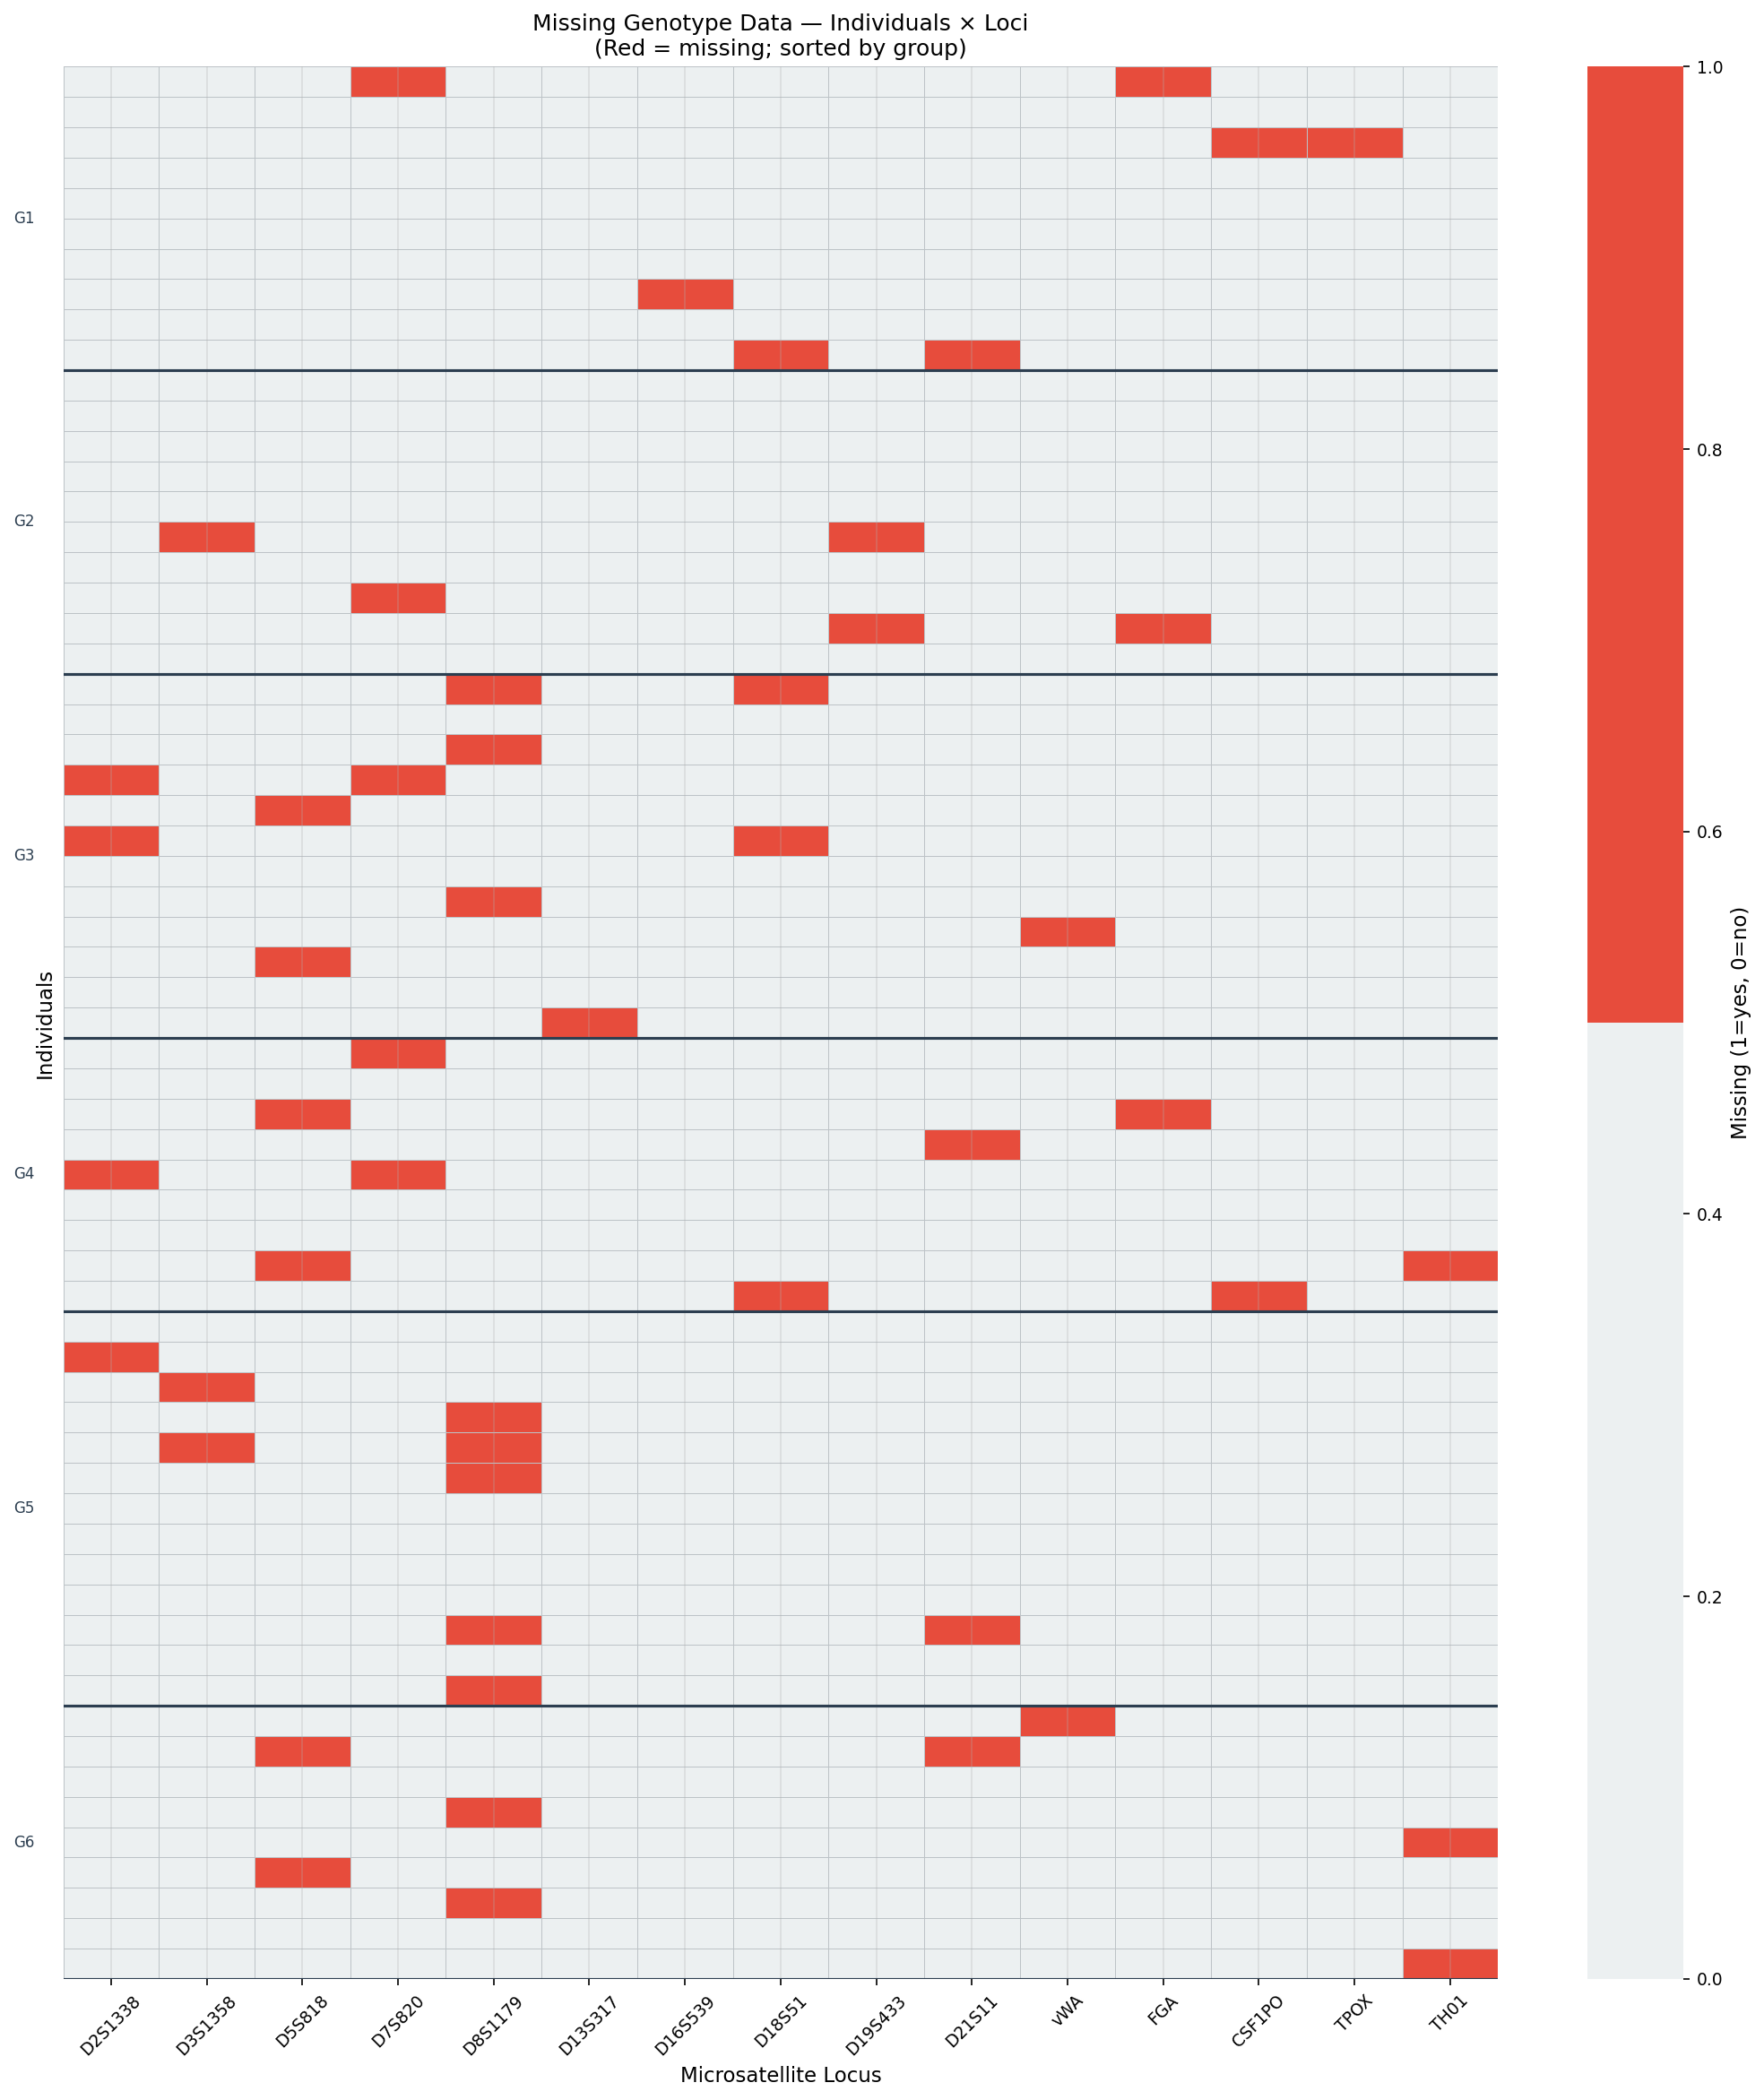

In [39]:
# Cell 8 — Missing data heatmap (individuals × loci)
import matplotlib.colors as mcolors

miss_mat = missing_data_matrix(geno_df, LOCUS_NAMES)

# Sort individuals by group
id_group = ind_df.set_index('individual_id')['group_id']
sorted_ids = id_group.sort_values().index.tolist()
miss_mat   = miss_mat.reindex(sorted_ids)

fig, ax = plt.subplots(figsize=(14, max(6, len(miss_mat)*0.25)))
cmap = mcolors.ListedColormap(['#ECF0F1', '#E74C3C'])
sns.heatmap(miss_mat, cmap=cmap, linewidths=0.3, linecolor='#BDC3C7',
            cbar_kws={'label': 'Missing (1=yes, 0=no)'}, ax=ax,
            xticklabels=True, yticklabels=False)
ax.set_title('Missing Genotype Data — Individuals × Loci\n(Red = missing; sorted by group)', fontsize=12)
ax.set_xlabel('Microsatellite Locus')
ax.set_ylabel('Individuals')
ax.tick_params(axis='x', rotation=45)

# Group boundary lines
prev = 0
for gid in sorted(id_group.unique()):
    n_in_group = (id_group == gid).sum()
    ax.axhline(prev + n_in_group, color='#2C3E50', lw=1.5)
    ax.text(-0.3, prev + n_in_group/2, gid, va='center', ha='right',
            fontsize=8, color='#2C3E50')
    prev += n_in_group

plt.tight_layout()
save_figure(fig, '01_missing_data_heatmap')
plt.show()

Individuals with >20% missing loci: 0
  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\01_individual_missing_data.png


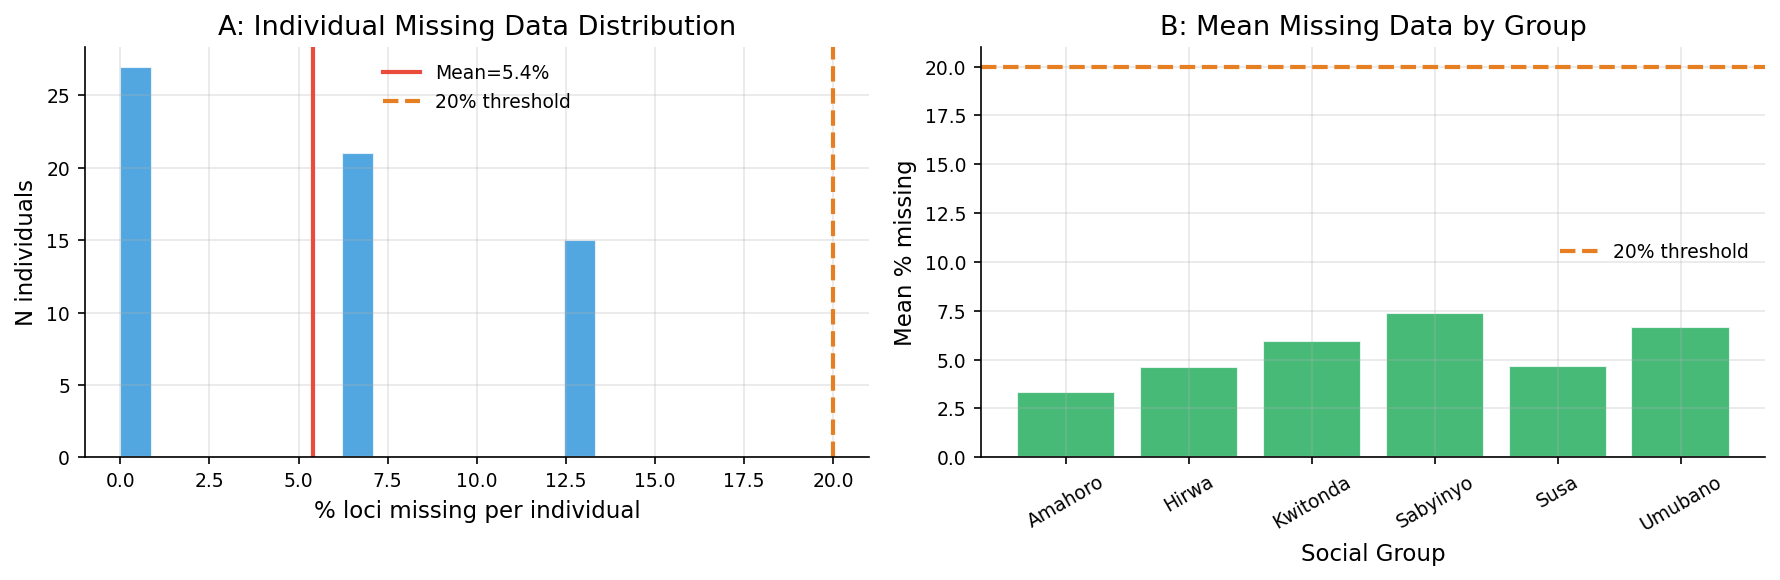

In [40]:
# Cell 9 — Per-individual missing data distribution
miss_ind = individual_missing_data(geno_df, LOCUS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(miss_ind['pct_missing'], bins=15, color='#3498DB', edgecolor='white', alpha=0.85)
ax.axvline(miss_ind['pct_missing'].mean(), color='#E74C3C', lw=2, label=f'Mean={miss_ind["pct_missing"].mean():.1f}%')
ax.axvline(20, color='#E67E22', lw=2, ls='--', label='20% threshold')
ax.set_xlabel('% loci missing per individual')
ax.set_ylabel('N individuals')
ax.set_title('A: Individual Missing Data Distribution')
ax.legend()

# Flag individuals with >20% missing
HIGH_MISS_INDS = miss_ind[miss_ind['pct_missing'] > 20]['individual_id'].tolist()
print(f'Individuals with >20% missing loci: {len(HIGH_MISS_INDS)}')

ax = axes[1]
# Group-level mean missing rate
miss_with_group = miss_ind.merge(ind_df[['individual_id','group_id']], on='individual_id')
miss_with_group = miss_with_group.merge(groups_df[['id','name']], left_on='group_id', right_on='id')
grp_miss = miss_with_group.groupby('name')['pct_missing'].mean()
ax.bar(grp_miss.index, grp_miss.values, color='#27AE60', edgecolor='white', alpha=0.85)
ax.axhline(20, color='#E67E22', lw=2, ls='--', label='20% threshold')
ax.set_xlabel('Social Group')
ax.set_ylabel('Mean % missing')
ax.set_title('B: Mean Missing Data by Group')
ax.tick_params(axis='x', rotation=30)
ax.legend()

plt.tight_layout()
save_figure(fig, '01_individual_missing_data')
plt.show()

In [41]:
# Cell 10 — Hardy-Weinberg Equilibrium tests + PIC per locus
freq_table = build_freq_table(geno_df, LOCUS_NAMES)

hwe_rows = []
for locus in LOCUS_NAMES:
    hwe = hwe_exact_chi2(geno_df, locus)
    pic = pic_per_locus(freq_table, locus)
    pe  = exclusion_probability_per_locus(freq_table, locus)
    hwe['PIC'] = round(pic, 4)
    hwe['PE']  = round(pe, 4)
    hwe_rows.append(hwe)

hwe_df = pd.DataFrame(hwe_rows)

# Bonferroni correction (15 tests)
alpha_bonf = 0.05 / len(LOCUS_NAMES)
hwe_df['HWE_fail'] = hwe_df['p_value'] < alpha_bonf

print(f'Hardy-Weinberg Equilibrium — Bonferroni-corrected α = {alpha_bonf:.4f}')
print(hwe_df[['locus','n','n_alleles','Ho','He','F_is','p_value','HWE_fail','PIC','PE']].to_string(index=False))
print()
print(f'Loci failing HWE: {hwe_df[hwe_df["HWE_fail"]]["locus"].tolist()}')
print(f'Mean PIC: {hwe_df["PIC"].mean():.4f}  (>0.5 = highly informative)')
print(f'Mean PE : {hwe_df["PE"].mean():.4f}')

cpe = combined_exclusion_probability(freq_table, LOCUS_NAMES)
print(f'Combined Exclusion Probability (all loci): {cpe:.6f}')
print(f'  → {100*cpe:.3f}% of random males are excluded by this panel')

hwe_df.to_csv(TAB_DIR / 'hwe_pic_summary.csv', index=False)

Hardy-Weinberg Equilibrium — Bonferroni-corrected α = 0.0033
  locus  n  n_alleles     Ho     He   F_is  p_value  HWE_fail    PIC     PE
D2S1338 59         13 0.7119 0.8862 0.1968   0.0000      True 0.8760 0.7751
D3S1358 60          7 0.6500 0.8249 0.2120   0.0004      True 0.8012 0.6567
 D5S818 57          9 0.7895 0.8270 0.0454   0.4535     False 0.8059 0.6628
 D7S820 58          9 0.7759 0.8291 0.0642   0.2817     False 0.8087 0.6670
D8S1179 53          9 0.7547 0.8491 0.1111   0.0551     False 0.8312 0.7030
D13S317 62          7 0.6774 0.8037 0.1571   0.0123     False 0.7784 0.6206
D16S539 62          7 0.7581 0.8258 0.0821   0.1594     False 0.8023 0.6585
 D18S51 59         11 0.7119 0.8065 0.1174   0.0657     False 0.7906 0.6346
D19S433 61          6 0.5738 0.7044 0.1854   0.0254     False 0.6727 0.4645
 D21S11 59         11 0.7288 0.8532 0.1458   0.0069     False 0.8367 0.7114
    vWA 61          8 0.6557 0.7386 0.1122   0.1405     False 0.7100 0.5170
    FGA 60         12 0.700

  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\01_locus_diagnostics.png


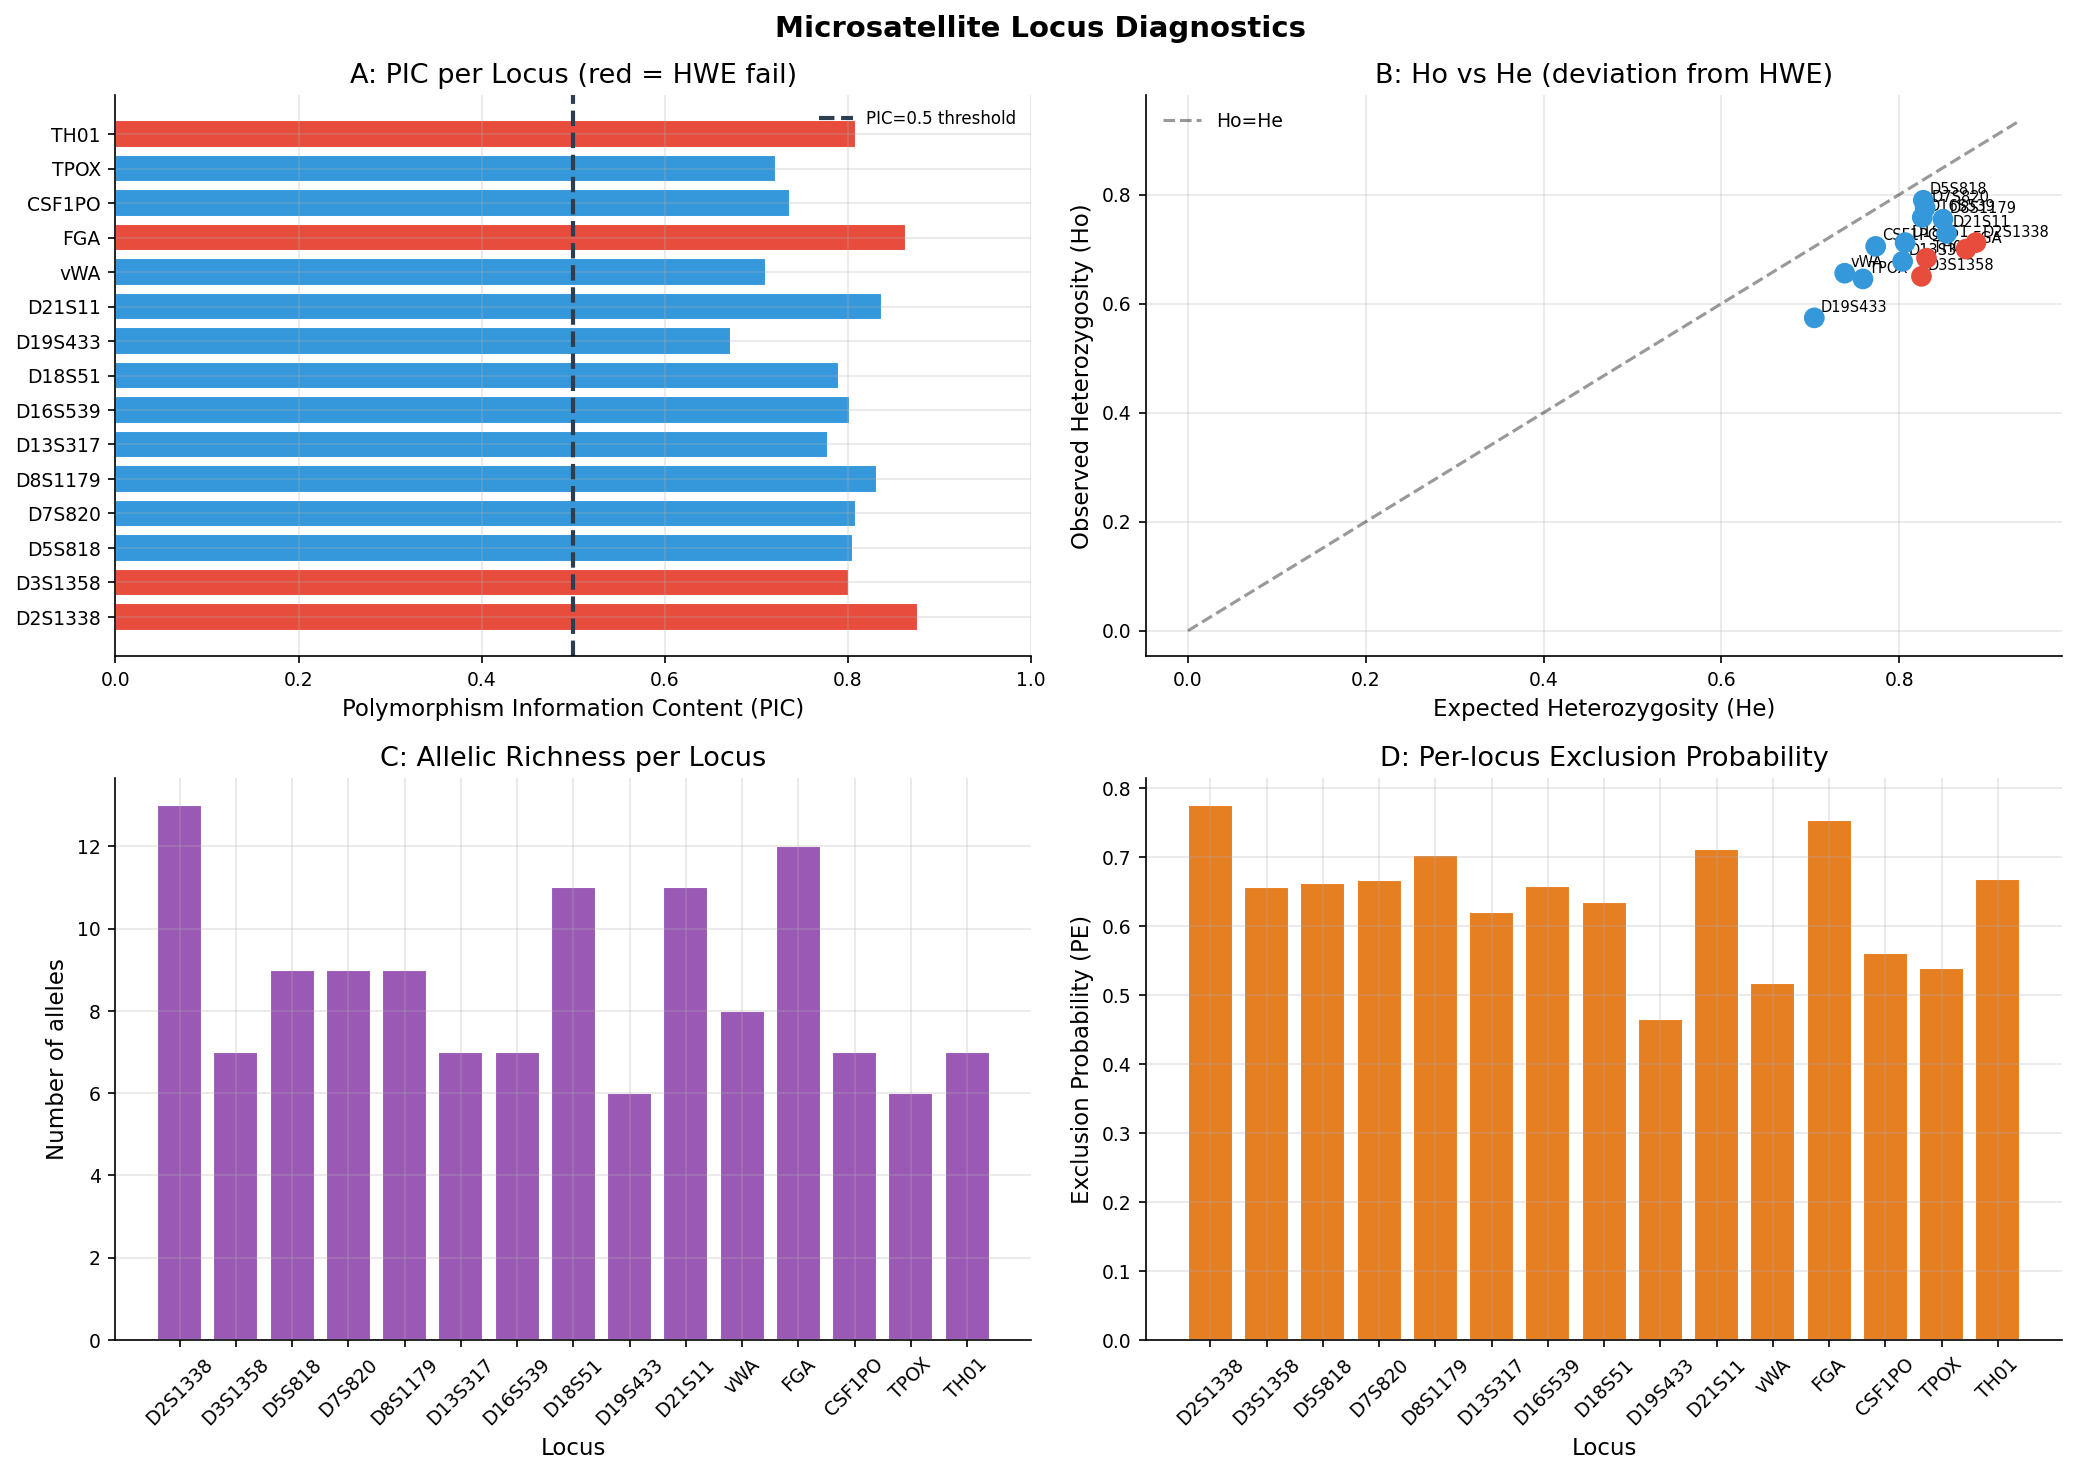

In [42]:
# Cell 11 — Locus statistics visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Microsatellite Locus Diagnostics', fontsize=14, fontweight='bold')

# Panel A: PIC per locus
ax = axes[0, 0]
colors_a = ['#E74C3C' if f else '#3498DB' for f in hwe_df['HWE_fail']]
ax.barh(hwe_df['locus'], hwe_df['PIC'], color=colors_a, edgecolor='white')
ax.axvline(0.5, color='#2C3E50', lw=2, ls='--', label='PIC=0.5 threshold')
ax.set_xlabel('Polymorphism Information Content (PIC)')
ax.set_title('A: PIC per Locus (red = HWE fail)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1)

# Panel B: Observed vs Expected Heterozygosity
ax = axes[0, 1]
ax.scatter(hwe_df['He'], hwe_df['Ho'], c=colors_a, s=80, zorder=5)
lim = max(hwe_df['He'].max(), hwe_df['Ho'].max()) + 0.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='Ho=He')
for _, row in hwe_df.iterrows():
    ax.annotate(row['locus'], (row['He'], row['Ho']),
                fontsize=7, xytext=(3,3), textcoords='offset points')
ax.set_xlabel('Expected Heterozygosity (He)')
ax.set_ylabel('Observed Heterozygosity (Ho)')
ax.set_title('B: Ho vs He (deviation from HWE)')
ax.legend()

# Panel C: Number of alleles per locus
ax = axes[1, 0]
ax.bar(hwe_df['locus'], hwe_df['n_alleles'], color='#9B59B6', edgecolor='white')
ax.set_xlabel('Locus')
ax.set_ylabel('Number of alleles')
ax.set_title('C: Allelic Richness per Locus')
ax.tick_params(axis='x', rotation=45)

# Panel D: Exclusion probability per locus
ax = axes[1, 1]
ax.bar(hwe_df['locus'], hwe_df['PE'], color='#E67E22', edgecolor='white')
ax.set_xlabel('Locus')
ax.set_ylabel('Exclusion Probability (PE)')
ax.set_title('D: Per-locus Exclusion Probability')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_figure(fig, '01_locus_diagnostics')
plt.show()

In [43]:
# Cell 12 — Apply QC filters and save cleaned dataset

# --- QC criteria (adjust as needed) ---
MAX_IND_MISSING   = 40.0   # % missing loci per individual
MAX_LOCUS_MISSING = 20.0   # % missing per locus
REMOVE_HWE_FAIL   = False  # Set True to remove loci failing HWE

# Step 1: Identify loci to keep
qc_loci = [l for l in LOCUS_NAMES
           if miss_locus[miss_locus['locus']==l]['pct_missing'].values[0] <= MAX_LOCUS_MISSING]
if REMOVE_HWE_FAIL:
    qc_loci = [l for l in qc_loci
               if l not in hwe_df[hwe_df['HWE_fail']]['locus'].tolist()]

# Step 2: Identify individuals to keep
miss_ind_updated = individual_missing_data(geno_df, qc_loci)
keep_inds = miss_ind_updated[miss_ind_updated['pct_missing'] <= MAX_IND_MISSING]['individual_id']

# Step 3: Filter
geno_qc = geno_df[geno_df['individual_id'].isin(keep_inds)].copy()
ind_qc  = ind_df[ind_df['individual_id'].isin(keep_inds)].copy()

print('=== QC FILTER SUMMARY ===')
print(f'Loci:        {len(LOCUS_NAMES)} → {len(qc_loci)} retained')
print(f'Individuals: {len(ind_df)} → {len(ind_qc)} retained')
print(f'Removed individuals: {len(ind_df) - len(ind_qc)}')
print()

# Save QC-filtered data
geno_qc.to_csv(PROC_DIR / 'genotypes_qc.csv', index=False)
ind_qc.to_csv(PROC_DIR / 'individuals_qc.csv', index=False)

# Save QC loci list
with open(PROC_DIR / 'qc_loci.txt', 'w') as f:
    f.write('\n'.join(qc_loci))

print(f'QC-filtered data saved to: {PROC_DIR}')
print(f'Loci used downstream: {qc_loci}')

=== QC FILTER SUMMARY ===
Loci:        15 → 15 retained
Individuals: 63 → 63 retained
Removed individuals: 0

QC-filtered data saved to: c:\Users\User\Desktop\gorilla-paternity-analysis\data\processed
Loci used downstream: ['D2S1338', 'D3S1358', 'D5S818', 'D7S820', 'D8S1179', 'D13S317', 'D16S539', 'D18S51', 'D19S433', 'D21S11', 'vWA', 'FGA', 'CSF1PO', 'TPOX', 'TH01']


In [44]:
# Cell 13 — QC summary table (for methods section)
qc_summary = pd.DataFrame({
    'Metric': [
        'Total loci genotyped',
        'Loci passing QC',
        'Mean PIC (passing loci)',
        'Combined exclusion probability',
        'Mean locus missing rate (%)',
        'Mean Ho (passing loci)',
        'Mean He (passing loci)',
        'Total individuals sampled',
        'Individuals passing QC',
        'Mean individual missing rate (%)',
    ],
    'Value': [
        len(LOCUS_NAMES),
        len(qc_loci),
        f"{hwe_df[hwe_df['locus'].isin(qc_loci)]['PIC'].mean():.4f}",
        f"{combined_exclusion_probability(freq_table, qc_loci):.6f}",
        f"{miss_locus[miss_locus['locus'].isin(qc_loci)]['pct_missing'].mean():.2f}",
        f"{hwe_df[hwe_df['locus'].isin(qc_loci)]['Ho'].mean():.4f}",
        f"{hwe_df[hwe_df['locus'].isin(qc_loci)]['He'].mean():.4f}",
        len(ind_df),
        len(ind_qc),
        f"{miss_ind_updated['pct_missing'].mean():.2f}",
    ]
})

print('=== QC SUMMARY (for Methods section) ===')
print(qc_summary.to_string(index=False))
qc_summary.to_csv(TAB_DIR / 'qc_summary.csv', index=False)
print('\nNotebook 01 complete. Proceed to 02_population_genetics.ipynb')

=== QC SUMMARY (for Methods section) ===
                          Metric    Value
            Total loci genotyped       15
                 Loci passing QC       15
         Mean PIC (passing loci)   0.7896
  Combined exclusion probability 1.000000
     Mean locus missing rate (%)     5.40
          Mean Ho (passing loci)   0.7014
          Mean He (passing loci)   0.8124
       Total individuals sampled       63
          Individuals passing QC       63
Mean individual missing rate (%)     5.40

Notebook 01 complete. Proceed to 02_population_genetics.ipynb
